# Fraud Detection

## Importing libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

## Load data

data source: https://www.kaggle.com/ealaxi/paysim1

In [2]:
df = pd.read_csv('./Datasets/PS_20174392719_1491204439457_log.csv')

## Check dimensions 

In [3]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## Data Cleaning and Preparation

### Check for nulls

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### Check for uniqueness 

In [7]:
df['nameDest'].nunique()

2722362

In [8]:
df['nameOrig'].nunique()

6353307

### Drop some columns 

In [9]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [10]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


## Data Exploration & Visualization

In [11]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

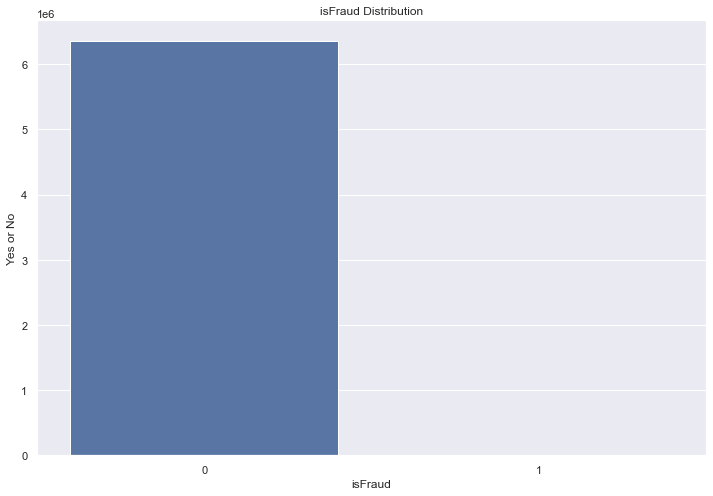

In [12]:
plt.figure(figsize=(12,8))

sns.countplot(x = 'isFraud', data=df)

plt.title('isFraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Yes or No')

plt.show()

In [13]:
df['isFlaggedFraud'].value_counts()

0    6362604
1         16
Name: isFlaggedFraud, dtype: int64

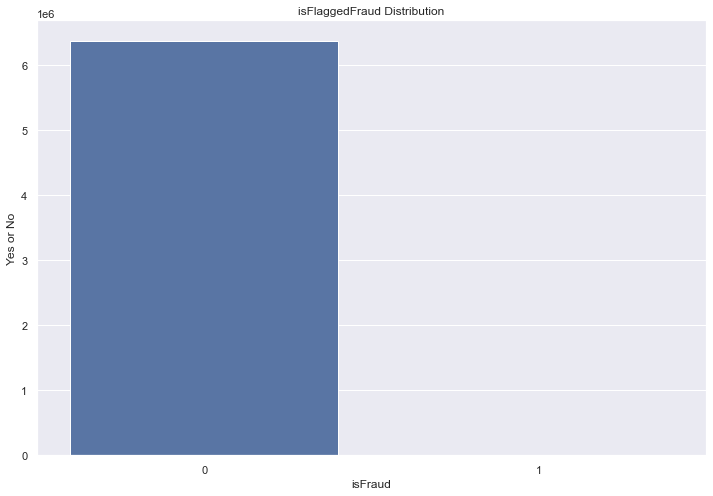

In [14]:
plt.figure(figsize=(12,8))

sns.countplot(x = 'isFlaggedFraud', data=df)

plt.title('isFlaggedFraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Yes or No')

plt.show()

<Figure size 864x576 with 0 Axes>

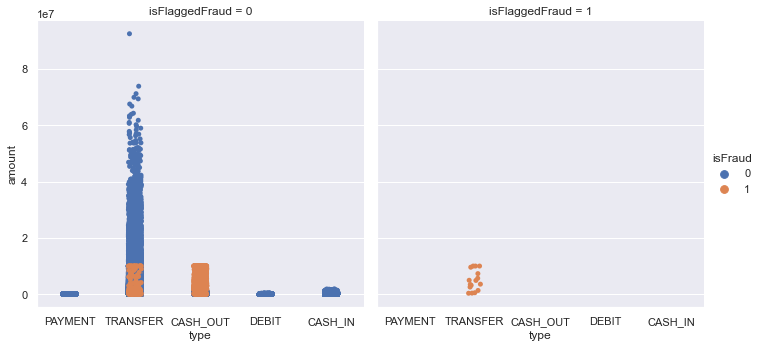

In [15]:
plt.figure(figsize=(12,8))

sns.catplot(x ='type', y ='amount', estimator = sum, hue ='isFraud', col='isFlaggedFraud', data=df)

plt.show()

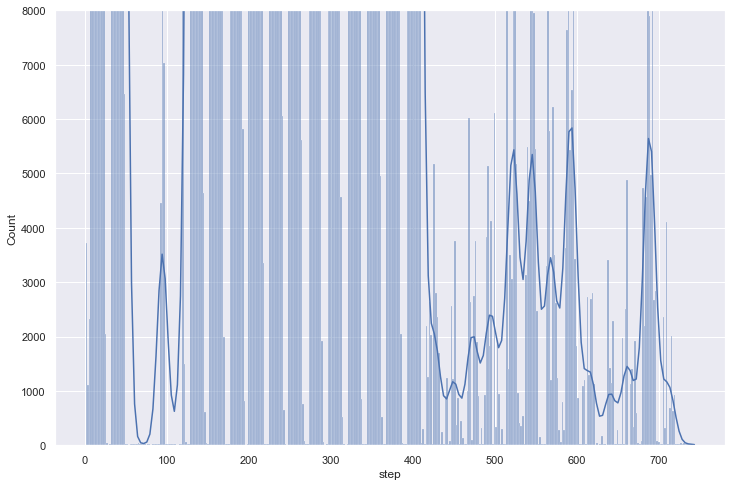

In [16]:
plt.figure(figsize=(12,8))

plt.ylim([0, 8000])
sns.histplot(df['step'], kde=True)

plt.show()

In [17]:
df['step'] = df['step'] % 24

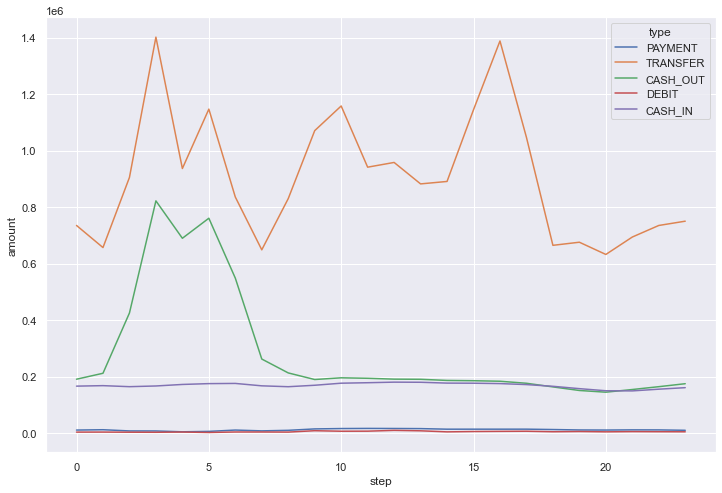

In [18]:
plt.figure(figsize=(12,8))

sns.lineplot(x ='step', y ='amount', hue = 'type', ci =None, estimator='mean', data=df)

plt.show()

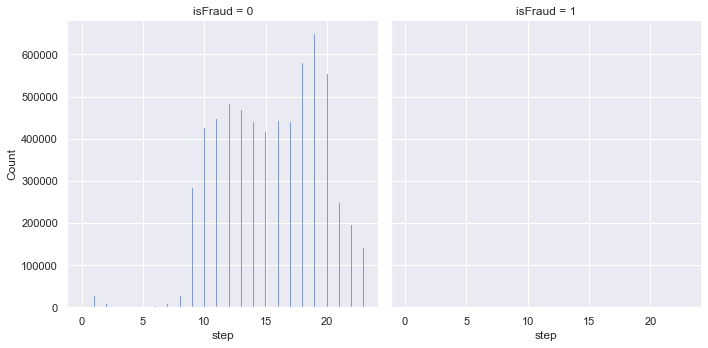

In [19]:
sns.displot(x ='step', col ='isFraud', data=df)

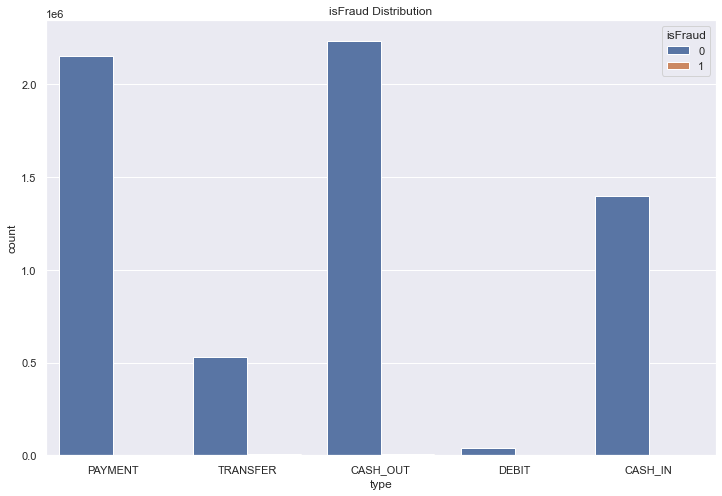

In [20]:
plt.figure(figsize=(12,8))

sns.countplot(x = 'type', hue = 'isFraud', data=df)

plt.title('isFraud Distribution')

plt.show()

In [21]:
df = df.loc[(df.type == 'TRANSFER')|(df.type == 'CASH_OUT')]

In [22]:
df.shape

(2770409, 9)

In [23]:
df.sample(10)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4447325,11,CASH_OUT,22506.14,8005.21,0.00,220115.80,242621.94,0,0
3545846,20,CASH_OUT,156889.07,0.00,0.00,1017599.90,1174488.97,0,0
3987915,10,CASH_OUT,43887.98,101158.00,57270.02,131471.15,175359.13,0,0
3853803,19,CASH_OUT,46523.43,30974.00,0.00,746272.70,792796.12,0,0
3999755,10,CASH_OUT,626236.11,591.00,0.00,0.00,626236.11,0,0
4558864,15,TRANSFER,4556822.83,5068.00,0.00,2185147.73,6741970.56,0,0
4467426,12,CASH_OUT,19127.01,0.00,0.00,10863469.83,10882596.85,0,0
5447820,19,CASH_OUT,22379.08,358182.19,335803.11,3031792.65,3054171.73,0,0
729673,13,CASH_OUT,27746.81,279098.54,251351.73,166374.74,194121.55,0,0
5040212,18,CASH_OUT,26975.39,0.00,0.00,57591.61,84567.00,0,0


### Convert to categorical

In [24]:
df = pd.concat([df, pd.get_dummies(df['type'], prefix='type', drop_first=True)], axis=1)

In [25]:
df.sample(10)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_TRANSFER
4795405,9,CASH_OUT,146084.44,9034.00,0.00,101505.84,247590.28,0,0,0
5534536,21,CASH_OUT,107133.57,5032.00,0.00,254940.69,362074.26,0,0,0
1928549,0,CASH_OUT,12562.87,0.00,0.00,633945.54,646508.41,0,0,0
6276612,15,TRANSFER,45890.12,45890.12,0.00,0.00,0.00,1,0,1
3124705,20,CASH_OUT,230785.11,0.00,0.00,863281.10,1094066.20,0,0,0
4785093,1,CASH_OUT,109390.77,8033.03,0.00,6810935.59,6920326.36,0,0,0
1598981,12,CASH_OUT,34447.68,68601.00,34153.32,3815067.75,3849515.44,0,0,0
3555329,20,CASH_OUT,62681.55,1039.00,0.00,0.00,62681.55,0,0,0
3716885,14,CASH_OUT,208132.24,0.00,0.00,738008.92,946141.17,0,0,0
148296,12,CASH_OUT,187039.15,262923.22,75884.07,275942.78,1749009.75,0,0,0


type_TRANSFER 0 is cash_out, type_TRANSFER 1 is transfer

### Drop more columns 

In [26]:
df.drop(['type', 'isFlaggedFraud'], axis=1, inplace=True)

In [27]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_TRANSFER
2,1,181.00,181.0,0.0,0.0,0.00,1,1
3,1,181.00,181.0,0.0,21182.0,0.00,1,0
15,1,229133.94,15325.0,0.0,5083.0,51513.44,0,0
19,1,215310.30,705.0,0.0,22425.0,0.00,0,1
24,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,1


In [28]:
df.dropna(inplace=True)

In [29]:
df['isFraud'].value_counts()

0    2762196
1       8213
Name: isFraud, dtype: int64

In [30]:
df['origBalanceDiscrepancy'] = df.newbalanceOrig + df.amount - df.oldbalanceOrg

In [31]:
df['destBalanceDiscrepancy'] = df.oldbalanceDest + df.amount - df.newbalanceDest

In [32]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_TRANSFER,origBalanceDiscrepancy,destBalanceDiscrepancy
2,1,181.00,181.0,0.0,0.0,0.00,1,1,0.00,181.0
3,1,181.00,181.0,0.0,21182.0,0.00,1,0,0.00,21363.0
15,1,229133.94,15325.0,0.0,5083.0,51513.44,0,0,213808.94,182703.5
19,1,215310.30,705.0,0.0,22425.0,0.00,0,1,214605.30,237735.3
24,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,1,300850.89,-2401220.0


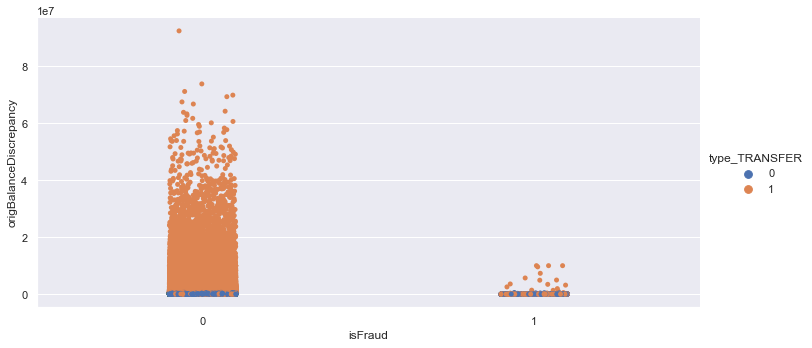

In [33]:
sns.catplot(x ='isFraud', y ='origBalanceDiscrepancy', estimator=sum, hue = 'type_TRANSFER', data=df, aspect=2)

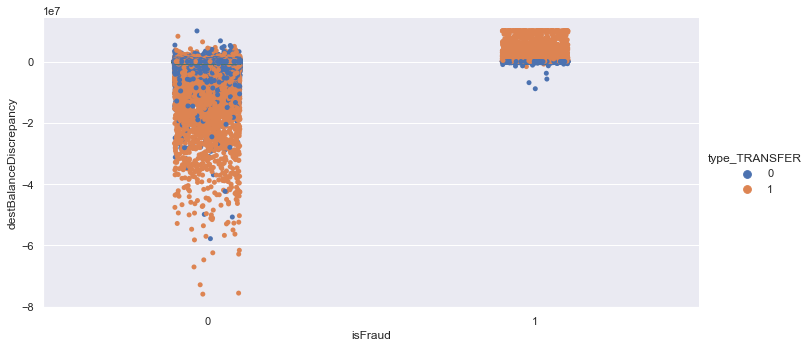

In [34]:
sns.catplot(x ='isFraud', y ='destBalanceDiscrepancy', estimator=sum, hue = 'type_TRANSFER', data=df, aspect=2)

In [35]:
df.to_csv('Datasets/prepared_data.csv', index=False)

## Machine Learning for Fraud Detection

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [37]:
df = pd.read_csv('Datasets/prepared_data.csv')

In [38]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_TRANSFER,origBalanceDiscrepancy,destBalanceDiscrepancy
0,1,181.00,181.0,0.0,0.0,0.00,1,1,0.00,181.0
1,1,181.00,181.0,0.0,21182.0,0.00,1,0,0.00,21363.0
2,1,229133.94,15325.0,0.0,5083.0,51513.44,0,0,213808.94,182703.5
3,1,215310.30,705.0,0.0,22425.0,0.00,0,1,214605.30,237735.3
4,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,1,300850.89,-2401220.0


### Train Test Split

In [39]:
X = df.drop(['isFraud'], axis=1)
y = df['isFraud']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [41]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1939286, 9), (831123, 9), (1939286,), (831123,))

### ML Models

### LogisticRegression()

In [42]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [43]:
y_pred_lr = model.predict(X_test)

In [44]:
print('Logistic Regression \n')

print('accuracy: ', accuracy_score(y_test, y_pred_lr))
print('precision: ', precision_score(y_test, y_pred_lr))
print('recall: ', recall_score(y_test, y_pred_lr))

Logistic Regression 

accuracy:  0.9981627268166083
precision:  0.8326848249027238
recall:  0.5029377203290247


### GaussianNB()

In [45]:
from sklearn.naive_bayes import GaussianNB

In [46]:
gauss_model = GaussianNB()

gauss_model.fit(X_train, y_train)

GaussianNB()

In [47]:
y_pred_gauss = gauss_model.predict(X_test)

In [48]:
print('naive_bayes \n')

print('accuracy: ', accuracy_score(y_test, y_pred_gauss))
print('precision: ', precision_score(y_test, y_pred_gauss))
print('recall: ', recall_score(y_test, y_pred_gauss))

naive_bayes 

accuracy:  0.9875072642677437
precision:  0.09854388843314192
recall:  0.3764198981590286


### SVC()

In [49]:
from sklearn.svm import SVC

In [50]:
svc_model = SVC()

svc_model.fit(X_train, y_train)

SVC()

In [51]:
y_pred_svc = svc_model.predict(X_test)

In [52]:
print('support vector classifier \n')

print('accuracy: ', accuracy_score(y_test, y_pred_svc))
print('precision: ', precision_score(y_test, y_pred_svc))
print('recall: ', recall_score(y_test, y_pred_svc))

support vector classifier 

accuracy:  0.9980183438552417
precision:  0.9860515021459227
recall:  0.3599686643164904


### Random Forests()

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [55]:
y_pred_rf = rf_model.predict(X_test)

In [56]:
print('RandomForestClassifier \n')

print('accuracy: ', accuracy_score(y_test, y_pred_rf))
print('precision: ', precision_score(y_test, y_pred_rf))
print('recall: ', recall_score(y_test, y_pred_rf))

RandomForestClassifier 

accuracy:  0.9999867648952081
precision:  0.9996069182389937
recall:  0.9960830395613004


### ROC & AUC Curves

In [57]:
from sklearn.metrics import auc, roc_curve

In [58]:
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_pred_lr)
auc_logistic = auc(fpr_logistic, tpr_logistic)

print('auc for logistic regression', auc_logistic)

auc for logistic regression 0.751313170240909


In [59]:
fpr_gauss, tpr_gauss, _ = roc_curve(y_test, y_pred_gauss)
auc_gauss = auc(fpr_gauss, tpr_gauss)

print('auc for gauss', auc_gauss)

auc for gauss 0.682905026139992


In [60]:
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_svc)
auc_svc = auc(fpr_svc, tpr_svc)

print('auc for svc', auc_svc)

auc for svc 0.6799764873171334


In [61]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print('auc for rf', auc_rf)

auc for rf 0.998040916331334


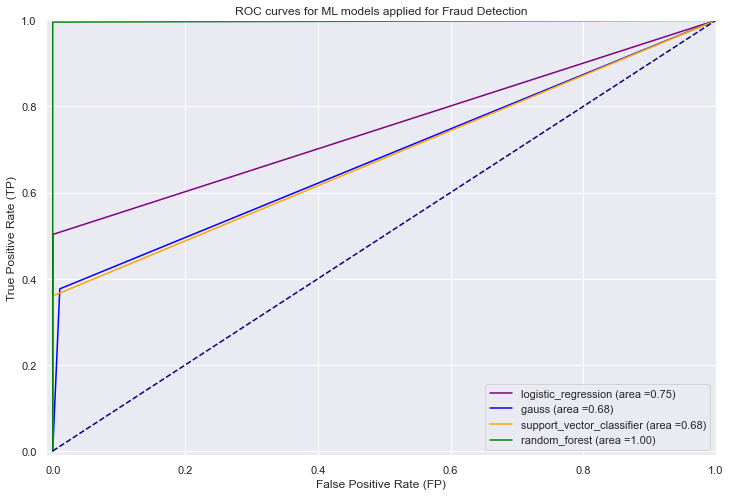

In [67]:
plt.figure(figsize=(12,8))

plt.plot(fpr_logistic, tpr_logistic, color='purple', label='logistic_regression (area =%0.2f)' %auc_logistic)
plt.plot(fpr_gauss, tpr_gauss, color='blue', label='gauss (area =%0.2f)' %auc_gauss)
plt.plot(fpr_svc, tpr_svc, color='orange', label='support_vector_classifier (area =%0.2f)' %auc_svc)
plt.plot(fpr_rf, tpr_rf, color='green', label='random_forest (area =%0.2f)' %auc_rf)

plt.plot([0,1], [0,1], color='navy', linestyle='--')

plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.0])

plt.xlabel('False Positive Rate (FP)')
plt.ylabel('True Positive Rate (TP)')
plt.title('ROC curves for ML models applied for Fraud Detection')
plt.legend(loc='lower right')
plt.show()